# Ev Harcamaları / REFIT Cihaz Kullanımı Analizi

Bu düzenlenmiş notebook, REFIT ev cihazı verilerinden kullanım olaylarını çıkarır, temizler, temel analizleri üretir ve karbon yoğunluğuna göre daha uygun çalışma saati önerisi verir. Gereksiz tekrarlar ve boş hücreler kaldırılmıştır.

## 1. Kütüphaneler

In [1]:
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Etkileşimli arayüz için kullanılır.
# Colab'da gerekiyorsa: !pip install ipywidgets
import ipywidgets as widgets
from IPython.display import clear_output, display


## 2. REFIT cihaz eşleştirme tablosu

REFIT veri setinde cihazlar `Appliance2`, `Appliance3` gibi sütun adlarıyla gelir. Aşağıdaki sözlük bu sütunları gerçek cihaz isimlerine çevirir.

In [2]:
# REFIT veri setindeki ev/cihaz sütunlarını okunabilir cihaz isimleriyle eşleştirir.
# Örnek: House_1.csv içindeki "Appliance5" sütunu çamaşır makinesini temsil eder.
appliance_map = {
    1: {"Appliance4": "tumble_dryer", "Appliance5": "washing_machine", "Appliance6": "dishwasher"},
    2: {"Appliance2": "washing_machine", "Appliance3": "dishwasher"},
    3: {"Appliance4": "tumble_dryer", "Appliance5": "dishwasher", "Appliance6": "washing_machine"},
    4: {"Appliance4": "washing_machine_1", "Appliance5": "washing_machine_2"},
    5: {"Appliance2": "tumble_dryer", "Appliance3": "washing_machine", "Appliance4": "dishwasher"},
    6: {"Appliance2": "washing_machine", "Appliance3": "dishwasher"},
    7: {"Appliance4": "tumble_dryer", "Appliance5": "washing_machine", "Appliance6": "dishwasher"},
    8: {"Appliance3": "dryer", "Appliance4": "washing_machine"},
    9: {"Appliance2": "washer_dryer", "Appliance3": "washing_machine", "Appliance4": "dishwasher"},
    10: {"Appliance5": "washing_machine", "Appliance6": "dishwasher"},
    11: {"Appliance3": "washing_machine", "Appliance4": "dishwasher"},
    13: {"Appliance3": "washing_machine", "Appliance4": "dishwasher", "Appliance5": "tumble_dryer"},
    15: {"Appliance2": "tumble_dryer", "Appliance3": "washing_machine", "Appliance4": "dishwasher"},
    16: {"Appliance5": "washing_machine", "Appliance6": "dishwasher"},
    17: {"Appliance3": "tumble_dryer", "Appliance4": "washing_machine"},
    18: {"Appliance4": "washer_dryer", "Appliance5": "washing_machine", "Appliance6": "dishwasher"},
    19: {"Appliance2": "washing_machine"},
    20: {"Appliance3": "tumble_dryer", "Appliance4": "washing_machine", "Appliance5": "dishwasher"},
    21: {"Appliance2": "tumble_dryer", "Appliance3": "washing_machine", "Appliance4": "dishwasher"},
}


## 3. Kullanım olayı çıkarma fonksiyonu

Bu fonksiyon güç tüketimi belirli bir eşik değerin üstüne çıktığında cihazı açık kabul eder ve ardışık açık ölçümleri tek bir kullanım olayı olarak toplar.

In [3]:
def extract_events_fast(df, house_id, appliance_col, appliance_name, threshold=20, min_duration_min=20):
    """
    Tek bir cihaz sütunundan cihaz kullanım olaylarını çıkarır.

    Mantık:
    1. Güç değeri threshold üstündeyse cihaz "açık" kabul edilir.
    2. Arka arkaya açık kalan ölçümler tek bir kullanım olayı/blok olarak gruplanır.
    3. Her olay için süre, enerji tüketimi, maksimum ve ortalama güç hesaplanır.
    """

    # Sadece zaman ve ilgili cihaz sütununu alıyoruz.
    temp = df[["Time", appliance_col]].copy()
    temp = temp.rename(columns={appliance_col: "power_watt"})

    # Zaman bilgisini datetime formatına çevirip sıralıyoruz.
    temp["Time"] = pd.to_datetime(temp["Time"])
    temp = temp.sort_values("Time").reset_index(drop=True)

    # Cihazın açık/kapalı durumunu belirliyoruz.
    temp["is_on"] = temp["power_watt"] > threshold

    # Durum değiştikçe yeni blok başlatılır: kapalı -> açık veya açık -> kapalı.
    temp["block_id"] = (temp["is_on"] != temp["is_on"].shift()).cumsum()

    # Ölçümler arası zaman farkı enerji hesabı için saat cinsinden hesaplanır.
    temp["time_diff_hours"] = temp["Time"].diff().dt.total_seconds().div(3600).fillna(0)

    # REFIT ölçümlerinde büyük zaman boşlukları olabilir; bunları enerji hesabına katmıyoruz.
    temp.loc[temp["time_diff_hours"] > (2 / 60), "time_diff_hours"] = 0

    # kWh = Watt x saat / 1000
    temp["energy_step_kwh"] = (temp["power_watt"] * temp["time_diff_hours"]) / 1000

    # Sadece cihaz açıkken oluşan blokları kullanım olayı olarak özetliyoruz.
    grouped = (
        temp[temp["is_on"]]
        .groupby("block_id")
        .agg(
            start_time=("Time", "min"),
            end_time=("Time", "max"),
            energy_kwh=("energy_step_kwh", "sum"),
            max_power_watt=("power_watt", "max"),
            mean_power_watt=("power_watt", "mean"),
        )
        .reset_index(drop=True)
    )

    if grouped.empty:
        return pd.DataFrame()

    # Olay süresini dakika cinsinden hesaplıyoruz.
    grouped["duration_min"] = (grouped["end_time"] - grouped["start_time"]).dt.total_seconds() / 60

    # Çok kısa/çok uzun veya fiziksel olarak anlamsız görünen olayları temizliyoruz.
    grouped = grouped[
        (grouped["duration_min"] >= min_duration_min) &
        (grouped["duration_min"] <= 300) &
        (grouped["energy_kwh"] > 0.05) &
        (grouped["energy_kwh"] < 10)
    ].copy()

    if grouped.empty:
        return pd.DataFrame()

    # Analiz için gerekli kimlik ve zaman bilgilerini ekliyoruz.
    grouped["house"] = f"House{house_id}"
    grouped["house_id"] = house_id
    grouped["appliance_name"] = appliance_name
    grouped["start_hour"] = grouped["start_time"].dt.hour
    grouped["start_date"] = grouped["start_time"].dt.date

    return grouped[[
        "house", "house_id", "appliance_name", "start_time", "end_time",
        "duration_min", "energy_kwh", "start_hour", "start_date",
        "max_power_watt", "mean_power_watt",
    ]]


## 4. REFIT CSV dosyalarını işleme

Bu hücre `House_1.csv`, `House_2.csv` gibi REFIT dosyalarını okur ve cihaz kullanım olaylarını `refit_appliance_events_fast.csv` dosyasına kaydeder.

In [4]:
# REFIT House_*.csv dosyalarının bulunduğu klasör.
# Notebook ile aynı klasördeyse Path(".") yeterlidir.
data_folder = Path(".")

raw_events_file = Path("refit_appliance_events_fast.csv")

# Eski çıktı varsa silinir; böylece aynı dosyaya tekrar tekrar ekleme yapılmaz.
if raw_events_file.exists():
    raw_events_file.unlink()

first_write = True

for house_id, devices in appliance_map.items():
    file_path = data_folder / f"House_{house_id}.csv"

    if not file_path.exists():
        print(f"Dosya bulunamadı: {file_path}")
        continue

    print(f"\nİşleniyor: House {house_id}")

    # Bellek kullanımını azaltmak için sadece gerekli sütunları okuyoruz.
    needed_cols = ["Time"] + list(devices.keys())
    df = pd.read_csv(file_path, usecols=lambda col: col.strip() in needed_cols)
    df.columns = df.columns.str.strip()

    house_events = []

    for appliance_col, appliance_name in devices.items():
        if appliance_col not in df.columns:
            print(f"{appliance_col} bulunamadı.")
            continue

        event_df = extract_events_fast(
            df=df,
            house_id=house_id,
            appliance_col=appliance_col,
            appliance_name=appliance_name,
            threshold=20,
            min_duration_min=20,
        )

        print(f"{appliance_name}: {len(event_df)} olay")

        if not event_df.empty:
            house_events.append(event_df)

    # Her evin olaylarını CSV dosyasına parça parça yazıyoruz.
    if house_events:
        house_events_df = pd.concat(house_events, ignore_index=True)
        house_events_df.to_csv(
            raw_events_file,
            mode="w" if first_write else "a",
            header=first_write,
            index=False,
        )
        first_write = False
        print(f"House {house_id} kaydedildi: {len(house_events_df)} olay")

    # Büyük CSV dosyalarıyla çalışırken belleği temizlemek faydalıdır.
    del df
    gc.collect()

print("\nOlay çıkarma işlemi tamamlandı.")



İşleniyor: House 1
tumble_dryer: 15 olay
washing_machine: 10 olay
dishwasher: 7 olay
House 1 kaydedildi: 32 olay

İşleniyor: House 2
washing_machine: 23 olay
dishwasher: 464 olay
House 2 kaydedildi: 487 olay

İşleniyor: House 3
tumble_dryer: 188 olay
dishwasher: 874 olay
washing_machine: 43 olay
House 3 kaydedildi: 1105 olay

İşleniyor: House 4
washing_machine_1: 25 olay
washing_machine_2: 15 olay
House 4 kaydedildi: 40 olay

İşleniyor: House 5
tumble_dryer: 539 olay
washing_machine: 274 olay
dishwasher: 707 olay
House 5 kaydedildi: 1520 olay

İşleniyor: House 6
washing_machine: 27 olay
dishwasher: 91 olay
House 6 kaydedildi: 118 olay

İşleniyor: House 7
tumble_dryer: 54 olay
washing_machine: 17 olay
dishwasher: 653 olay
House 7 kaydedildi: 724 olay

İşleniyor: House 8
dryer: 75 olay
washing_machine: 180 olay
House 8 kaydedildi: 255 olay

İşleniyor: House 9
washer_dryer: 324 olay
washing_machine: 72 olay
dishwasher: 366 olay
House 9 kaydedildi: 762 olay

İşleniyor: House 10
washing_ma

## 5. Olay verisini temizleme

Aynı cihaz isimleri birleştirilir ve uç/gürültülü kayıtlar filtrelenir. Nihai çıktı `refit_appliance_events_final.csv` dosyasıdır.

In [5]:
events_df = pd.read_csv("refit_appliance_events_fast.csv")

# Aynı anlamdaki cihaz isimlerini tek isim altında topluyoruz.
events_df["appliance_name"] = events_df["appliance_name"].replace({
    "washing_machine_1": "washing_machine",
    "washing_machine_2": "washing_machine",
    "dryer": "tumble_dryer",
})

# Nihai analiz için daha güvenilir olayları seçiyoruz.
# Bu filtreler çok düşük enerji, aşırı uzun süre ve düşük maksimum güç gibi gürültülü kayıtları azaltır.
events_final = events_df[
    (events_df["energy_kwh"] >= 0.15) &
    (events_df["energy_kwh"] <= 4.0) &
    (events_df["duration_min"] >= 20) &
    (events_df["duration_min"] <= 180) &
    (events_df["max_power_watt"] >= 500)
].copy()

# Temizlenmiş veri daha sonraki analiz ve arayüz adımlarında kullanılacak.
events_final.to_csv("refit_appliance_events_final.csv", index=False)

events_final.groupby("appliance_name")[["energy_kwh", "duration_min", "max_power_watt"]].describe().round(3)


energy_kwh                                                   \
                     count   mean    std    min    25%    50%    75%    max   
appliance_name                                                                
dishwasher          4944.0  0.633  0.178  0.153  0.490  0.613  0.767  3.161   
tumble_dryer        1183.0  1.007  0.627  0.156  0.568  0.820  1.248  3.733   
washer_dryer         313.0  0.648  0.309  0.201  0.449  0.560  0.768  2.284   
washing_machine      800.0  0.917  0.371  0.158  0.703  0.843  1.108  3.758   

                duration_min          ...                  max_power_watt  \
                       count    mean  ...     75%      max          count   
appliance_name                        ...                                   
dishwasher            4944.0  48.105  ...  69.950  118.133         4944.0   
tumble_dryer          1183.0  47.863  ...  61.150  174.767         1183.0   
washer_dryer           313.0  34.855  ...  39.983  149.567          313.0   
washing_machine        800.0  32.139  ...  34.033  174.283          800.0   

                                                                           
                     mean      std    min     25%     50%     75%     max  
appliance_name                                                             
dishwasher       2216.321  235.953  512.0  2112.0  2220.0  2327.0  3706.0  
tumble_dryer     2140.876  478.254  512.0  1927.5  2033.0  2525.0  3922.0  
washer_dryer     1869.160  560.873  512.0  1475.0  1503.0  2598.0  2746.0  
washing_machine  2214.826  400.014  500.0  2151.0  2298.0  2413.0  2789.0  

[4 rows x 24 columns]

## 6. Temel veri kontrolü

In [6]:
df = pd.read_csv("refit_appliance_events_final.csv")

# Zaman sütunlarını datetime formatına çeviriyoruz.
df["start_time"] = pd.to_datetime(df["start_time"])
df["end_time"] = pd.to_datetime(df["end_time"])

# Görselleştirme ve özet tablolar için zaman özellikleri üretiyoruz.
df["start_date"] = df["start_time"].dt.date
df["start_hour"] = df["start_time"].dt.hour
df["day_of_week"] = df["start_time"].dt.day_name()

print("Satır sayısı:", df.shape[0])
print("Sütun sayısı:", df.shape[1])
df.head()


Satır sayısı: 7240
Sütun sayısı: 12


,house,house_id,appliance_name,start_time,end_time,duration_min,energy_kwh,start_hour,start_date,max_power_watt,mean_power_watt,day_of_week
0,House1,1,tumble_dryer,2013-10-27 14:23:14,2013-10-27 14:47:18,24.066667,0.470819,14,2013-10-27,2647,1171.995885,Sunday
1,House1,1,tumble_dryer,2013-12-26 12:06:34,2013-12-26 12:33:21,26.783333,0.610967,12,2013-12-26,1469,1358.815534,Thursday
2,House1,1,tumble_dryer,2013-12-28 14:07:15,2013-12-28 14:27:33,20.300000,0.594763,14,2013-12-28,2571,1706.454023,Saturday
3,House1,1,tumble_dryer,2014-07-11 05:03:09,2014-07-11 06:12:21,69.200000,0.535509,5,2014-07-11,520,448.396694,Friday
4,House1,1,tumble_dryer,2014-09-19 06:05:20,2014-09-19 06:26:10,20.833333,0.428015,6,2014-09-19,2625,1203.422535,Friday


## 7. Cihaz bazında özet tablo

In [7]:
summary_table = (
    df.groupby("appliance_name")
    .agg(
        event_count=("appliance_name", "count"),
        mean_energy_kwh=("energy_kwh", "mean"),
        median_energy_kwh=("energy_kwh", "median"),
        mean_duration_min=("duration_min", "mean"),
        median_duration_min=("duration_min", "median"),
        mean_max_power_watt=("max_power_watt", "mean"),
    )
    .round(3)
    .sort_values("event_count", ascending=False)
)

summary_table


,event_count,mean_energy_kwh,median_energy_kwh,mean_duration_min,median_duration_min,mean_max_power_watt
appliance_name,,,,,,
dishwasher,4944,0.633,0.613,48.105,42.483,2216.321
tumble_dryer,1183,1.007,0.820,47.863,34.583,2140.876
washing_machine,800,0.917,0.843,32.139,26.242,2214.826
washer_dryer,313,0.648,0.560,34.855,29.517,1869.160


## 8. Temel görselleştirmeler

Sunum ve rapor için en anlaşılır üç grafik bırakılmıştır: olay sayısı, medyan enerji tüketimi ve saatlik kullanım dağılımı.

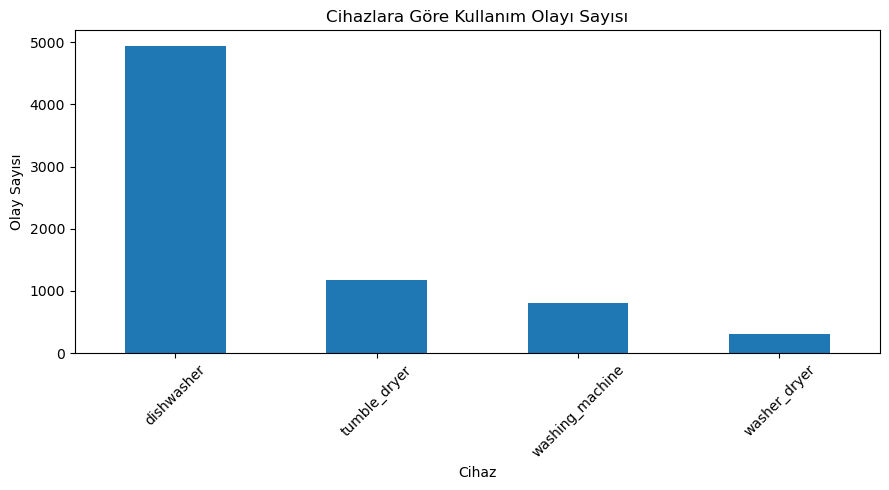

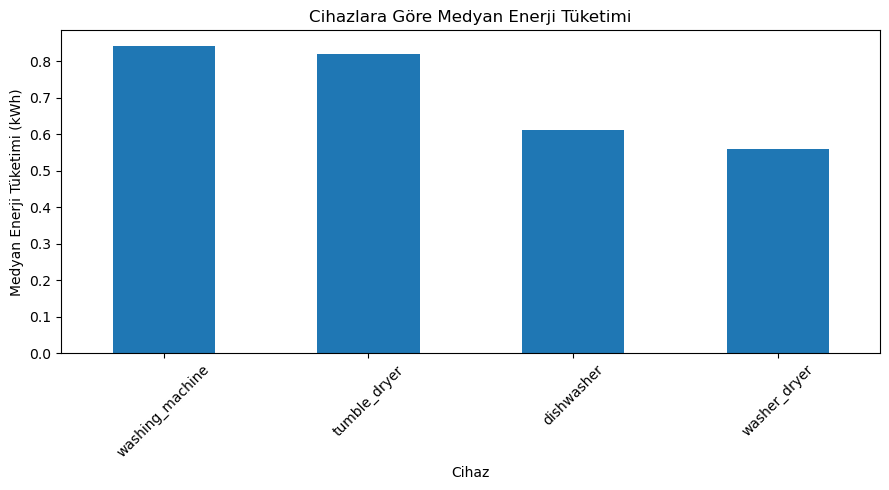

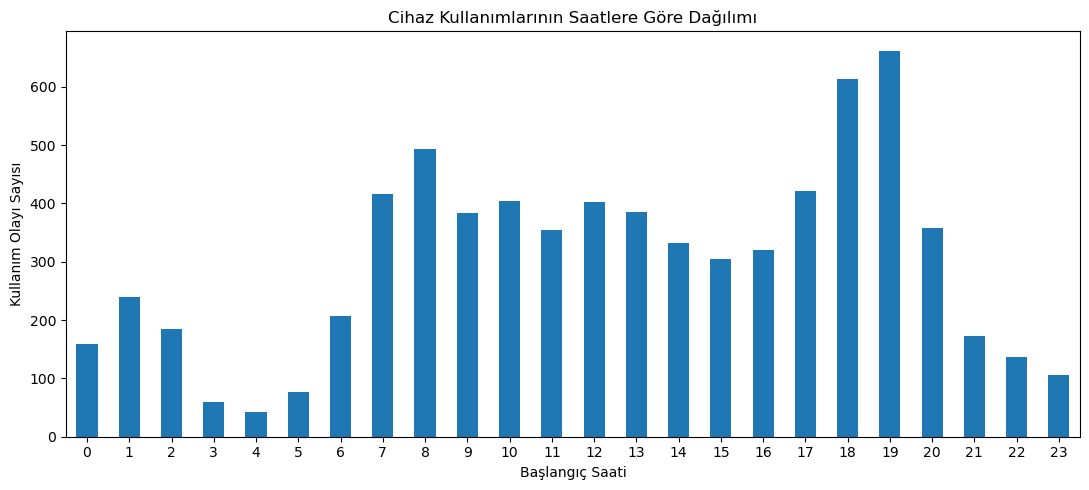

In [8]:
# 1) Cihazlara göre kullanım olayı sayısı
event_counts = df["appliance_name"].value_counts()

plt.figure(figsize=(9, 5))
event_counts.plot(kind="bar")
plt.title("Cihazlara Göre Kullanım Olayı Sayısı")
plt.xlabel("Cihaz")
plt.ylabel("Olay Sayısı")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2) Cihazlara göre medyan enerji tüketimi
median_energy = df.groupby("appliance_name")["energy_kwh"].median().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
median_energy.plot(kind="bar")
plt.title("Cihazlara Göre Medyan Enerji Tüketimi")
plt.xlabel("Cihaz")
plt.ylabel("Medyan Enerji Tüketimi (kWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3) Başlangıç saatlerine göre kullanım yoğunluğu
hour_counts = df["start_hour"].value_counts().sort_index()

plt.figure(figsize=(11, 5))
hour_counts.plot(kind="bar")
plt.title("Cihaz Kullanımlarının Saatlere Göre Dağılımı")
plt.xlabel("Başlangıç Saati")
plt.ylabel("Kullanım Olayı Sayısı")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 9. Karbon yoğunluğu ve cihaz enerji istatistikleri

In [9]:
# Örnek saatlik karbon yoğunluğu tablosu.
# Gerçek uygulamada bu değerler güncel şebeke/veri kaynağından alınabilir.
carbon_df = pd.DataFrame({
    "hour": list(range(24)),
    "carbon_intensity_g_per_kwh": [
        310, 280, 240, 230, 250, 270,
        300, 360, 390, 410, 380, 340,
        300, 270, 260, 280, 330, 390,
        430, 450, 440, 400, 360, 330,
    ],
})

# Her cihaz için REFIT verisinden medyan enerji tüketimini alıyoruz.
# Arayüzde cihaz seçildiğinde varsayılan enerji değeri bu tablodan gelecek.
device_energy_stats = (
    df.groupby("appliance_name")["energy_kwh"]
    .median()
    .round(3)
    .to_dict()
)

carbon_df


,hour,carbon_intensity_g_per_kwh
0,0,310
1,1,280
2,2,240
3,3,230
4,4,250
5,5,270
6,6,300
7,7,360
8,8,390
9,9,410


## 10. Karbon tasarrufu hesaplama fonksiyonu

In [10]:
def calculate_carbon_recommendation(device_name, current_hour, energy_kwh):
    """
    Seçilen cihaz için mevcut kullanım saatindeki emisyonu ve
    en düşük karbon yoğunluğuna sahip saate kaydırıldığında oluşabilecek kazancı hesaplar.
    """

    current_hour = int(current_hour)
    energy_kwh = float(energy_kwh)

    # Kullanıcının seçtiği saatteki karbon yoğunluğu.
    current_carbon = carbon_df.loc[
        carbon_df["hour"] == current_hour,
        "carbon_intensity_g_per_kwh",
    ].values[0]

    # Gün içindeki en düşük karbon yoğunluğuna sahip saat.
    best_row = carbon_df.loc[carbon_df["carbon_intensity_g_per_kwh"].idxmin()]
    recommended_hour = int(best_row["hour"])
    recommended_carbon = float(best_row["carbon_intensity_g_per_kwh"])

    # Emisyon hesabı: kWh x gCO₂/kWh = gCO₂
    current_emission = energy_kwh * current_carbon
    recommended_emission = energy_kwh * recommended_carbon

    saving_g = current_emission - recommended_emission
    saving_percent = (saving_g / current_emission * 100) if current_emission > 0 else 0

    return {
        "device_name": device_name,
        "current_hour": current_hour,
        "recommended_hour": recommended_hour,
        "energy_kwh": energy_kwh,
        "current_carbon": current_carbon,
        "recommended_carbon": recommended_carbon,
        "current_emission": current_emission,
        "recommended_emission": recommended_emission,
        "saving_g": saving_g,
        "saving_percent": saving_percent,
    }


## 11. Etkileşimli öneri arayüzü

Kullanıcı cihazı ve mevcut kullanım saatini seçer. Sistem, REFIT verisinden gelen medyan enerji tüketimini kullanarak daha düşük karbonlu saat önerisi üretir.

In [11]:
# Cihaz seçimi: REFIT verisinde bulunan cihazlar listelenir.
device_dropdown = widgets.Dropdown(
    options=sorted(df["appliance_name"].unique()),
    value="washing_machine" if "washing_machine" in df["appliance_name"].unique() else sorted(df["appliance_name"].unique())[0],
    description="Cihaz:",
    style={"description_width": "initial"},
)

# Kullanıcının cihazı çalıştırmayı düşündüğü saat.
hour_slider = widgets.IntSlider(
    value=19,
    min=0,
    max=23,
    step=1,
    description="Mevcut Saat:",
    style={"description_width": "initial"},
    continuous_update=False,
)

# Varsayılan olarak cihazın REFIT verisindeki medyan enerji tüketimi gelir.
energy_input = widgets.FloatText(
    value=device_energy_stats.get(device_dropdown.value, 1.0),
    description="Enerji (kWh):",
    style={"description_width": "initial"},
)

manual_energy_checkbox = widgets.Checkbox(
    value=False,
    description="Enerji değerini manuel gireceğim",
)

calculate_button = widgets.Button(
    description="CO₂ Önerisi Hesapla",
    button_style="success",
)

output = widgets.Output()


def update_energy_value(change):
    """Cihaz değiştiğinde, manuel giriş kapalıysa enerji değerini otomatik günceller."""
    selected_device = change["new"]

    if not manual_energy_checkbox.value:
        energy_input.value = device_energy_stats.get(selected_device, 1.0)


def on_calculate_clicked(button):
    """Butona basıldığında öneriyi hesaplar, metin ve grafik olarak gösterir."""
    with output:
        clear_output()

        result = calculate_carbon_recommendation(
            device_name=device_dropdown.value,
            current_hour=hour_slider.value,
            energy_kwh=energy_input.value,
        )

        print("CARBON-AWARE DEMAND COACH")
        print("-" * 45)
        print(f"Cihaz: {result['device_name']}")
        print(f"Mevcut kullanım saati: {result['current_hour']:02d}:00")
        print(f"Önerilen kullanım saati: {result['recommended_hour']:02d}:00")
        print(f"Enerji tüketimi: {result['energy_kwh']:.3f} kWh")
        print()
        print(f"Mevcut karbon yoğunluğu: {result['current_carbon']:.1f} gCO₂/kWh")
        print(f"Önerilen saat karbon yoğunluğu: {result['recommended_carbon']:.1f} gCO₂/kWh")
        print()
        print(f"Mevcut emisyon: {result['current_emission']:.1f} gCO₂")
        print(f"Önerilen emisyon: {result['recommended_emission']:.1f} gCO₂")
        print(f"Tahmini CO₂ kazancı: {result['saving_g']:.1f} gCO₂")
        print(f"Azalma oranı: %{result['saving_percent']:.1f}")
        print()

        if result["saving_g"] > 0:
            print(
                f"Öneri: {result['device_name']} cihazını "
                f"{result['current_hour']:02d}:00 yerine "
                f"{result['recommended_hour']:02d}:00 saatinde çalıştırırsanız "
                f"yaklaşık %{result['saving_percent']:.1f} daha az CO₂ salımı oluşur."
            )
        else:
            print("Bu cihaz zaten en düşük karbon yoğunluğuna yakın bir saatte çalıştırılıyor.")

        # Saatlik karbon yoğunluğu grafiği üzerinde mevcut ve önerilen saat gösterilir.
        plt.figure(figsize=(12, 5))
        plt.plot(carbon_df["hour"], carbon_df["carbon_intensity_g_per_kwh"], marker="o")
        plt.scatter(result["current_hour"], result["current_carbon"], s=140, label="Mevcut Saat")
        plt.scatter(result["recommended_hour"], result["recommended_carbon"], s=140, label="Önerilen Saat")
        plt.title("Saatlik Karbon Yoğunluğu ve Önerilen Kullanım Saati")
        plt.xlabel("Saat")
        plt.ylabel("Karbon Yoğunluğu (gCO₂/kWh)")
        plt.xticks(range(24))
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


device_dropdown.observe(update_energy_value, names="value")
calculate_button.on_click(on_calculate_clicked)

ui = widgets.VBox([
    widgets.HTML("<h2>Carbon-Aware Demand Coach</h2>"),
    widgets.HTML("<p>Ev cihazları için daha düşük karbonlu çalışma saati önerisi</p>"),
    device_dropdown,
    hour_slider,
    manual_energy_checkbox,
    energy_input,
    calculate_button,
    output,
])

display(ui)
